|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

### Problème 2C4 

#### Exercice de très bon niveau, qui démontre encore une fois les grandes capacités de calcul symbolique de SYMPY et la capacité de compléter les analyses avec des graphes montrant les caractéristiques des solutions.

> La différence entre ce problème de niveau C et les problèmes de niveau B est principalement due à la pose et à la solution de la condition aux limites qui est différente de celle utilisée à la section 2.4:

>> * Le cylindre central se déplaçant, il affecte le débit de fluide qui s'écoule entre le cylindre et la paroi. Ceci ajoute donc un degré de liberté à la solution qui devient mathématiquement plus complexe et qui ajoute des manipulations. C'est là ou l'utilisation d'un outil de calcul symbolique devient très intéressant car il prendra en charge pratiquement toute la complexité ajoutée par cette nouvelle condition

<img src='../images/Chap-2-Prob-2C4.png' height=60% width=60%>

La solution obtenue à la section 2.4 est valide en partie, les constantes devront être revues car les pressions ne sont pas connues dans ce cas. On reprend donc la section 2.4 à partir de 2.4-1.

In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
r,delta_r,H,mu,R,DP,kappa,rho,g,theta=sp.symbols('r,delta_r,H,mu,R,\Delta{}P,kappa,rho,g,theta')    
vz=sp.Function('v_z')(r)
v0=sp.symbols('v_0')
taurz=sp.Function('tau_rz')
newton=-mu*sp.Derivative(vz,r) 
eq1=sp.Eq(sp.diff(r*taurz(r))-(DP)*r/H,0)     
# 2.4-1 de Bird, avec le P = P rond qui additionne la pression et la gravité. Ca simplifie la notation
# Comme dans le chapitre 2 à dans les sections 2.3 et 2.4, Prond=P(+-)rho g z avec le (+-) dépendant de
# l'orientation de la gravité par rapport à l'axe des z.
eq1=sp.dsolve(eq1)
display(eq1)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_186069/4289455630.py:1: SyntaxWarning: invalid escape sequence '\D'
  r,delta_r,H,mu,R,DP,kappa,rho,g,theta=sp.symbols('r,delta_r,H,mu,R,\Delta{}P,kappa,rho,g,theta')


In [3]:
eq2=eq1.subs(taurz(r),newton)
display(eq2)

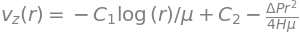

In [4]:
vz=sp.dsolve(eq2,vz)
display(vz)

#### a) Les deux constantes C1 et C2 sont inconnues **ainsi** que $\Delta P$ dans ce problème, car la différence de pression entre le haut et le bas du cylindre est une variable dépendant des conditions. On a alors 3 équations à trois inconnues à résoudre, on a déjà les deux conditions de non glissement mais il nous en manque une, celle-ci:

 le débit de liquide est égal au déplacement de liquide causé par le mouvement du piston, donc on a que 
> troisième condition aux limites: on a que
>>  $  Q =  \int_{0}^{2\pi} \int_{\kappa R}^{R} r v_z(r)dr d\theta $
>> est égal au volume de fluide déplacé par la chute du piston soit:
>> $ Q = v_0 \pi \kappa^2 R^2 $ 
#### 3 équations à trois inconnues, très lourd à faire à la main, mais pas pour un calculateur symbolique.

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_186069/4009287829.py:6: SyntaxWarning: invalid escape sequence '\D'
  constantes=sp.solve([condition_1,condition_2,condition_3],sp.symbols('C1,C2,\Delta{}P'))


'Les 3 conditions aux limites pour trouver les 3 constantes inconnues C1,C2 et DeltaP'

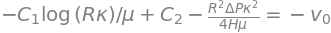

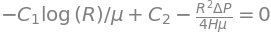

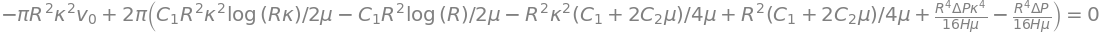

'constantes'

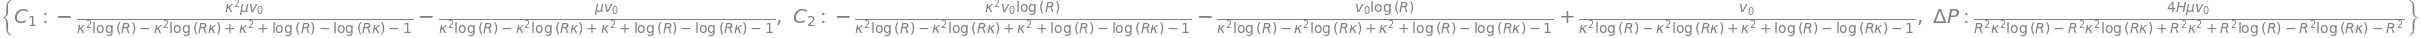

In [5]:
vz=vz.rhs
condition_1=sp.Eq(vz.subs(r,kappa*R),-v0)
condition_2=sp.Eq(vz.subs(r,R      ),0)
condition_3=sp.Eq(sp.integrate((r*vz),(r,kappa*R,R),(theta,0,2*sp.pi))-v0*sp.pi*kappa**2*R**2,0)
display('Les 3 conditions aux limites pour trouver les 3 constantes inconnues C1,C2 et DeltaP',condition_1,condition_2,condition_3)
constantes=sp.solve([condition_1,condition_2,condition_3],sp.symbols('C1,C2,\Delta{}P'))
display('constantes',constantes)

>> Vérifions si le profil est identique à celui donné dans Transport Phenomena

'profil de vitesse après substitution des 3 constantes'

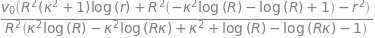

In [6]:
vz=vz.subs(constantes)
display('profil de vitesse après substitution des 3 constantes',vz.simplify())

#### b) Bilan de forces sur le piston : poids = forces de friction + forces de pressions
>> donc 
>>> $(\Delta \rho )\pi \kappa^2 R^2 H g = 2 \pi \kappa R H {\tau_{rz}}|_{r=\kappa R} + \Delta{P} \pi \kappa^2 R^2$

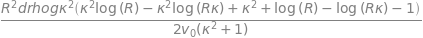

In [7]:
drho,g=sp.symbols('drho g')
poids=-drho*sp.pi*kappa**2*R**2*H*g
friction=2*sp.pi*kappa*R*H*(-mu*vz.diff(r).subs(r,kappa*R))
diff_pression=-DP*sp.pi*kappa**2*R**2
eq=sp.Eq((poids-friction-diff_pression),0)
eq=eq.subs(constantes)      # on fait ceci car on a DP, une des trois constantes inconnues
mu1=sp.solve(eq,mu)         # trouvées ci-haut. 
mu=mu1.pop()
display(mu.simplify())

>> Comparons maintenant ce résultat avec 2C4.2, en principe la seule différence est la mise en forme. On utilisera des valeurs estimées pour les paramètres.

In [8]:
dico={'R':0.01,'kappa':0.8,'v_0':0.01,'drho':100,'g':9.81}
display(mu.subs(dico))
muBird=(drho*g*kappa**2*R**2)/(2*v0)*(sp.log(1/kappa)-(1-kappa**2)/(1+kappa**2))
display(muBird.subs(dico))

Dernière vérification, mettons la viscosité calculée dans le profil de vitesse et tracons.

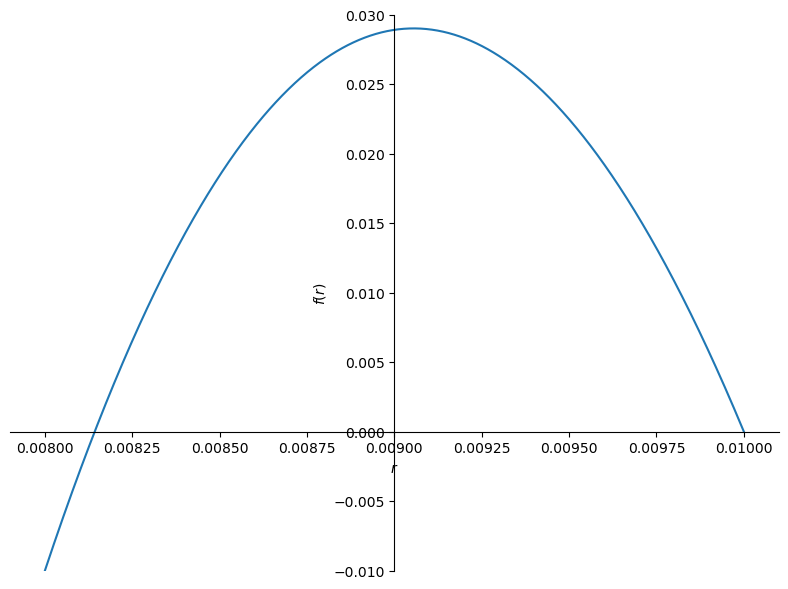

In [9]:
dico['mu']=mu.subs(dico).evalf()   # ajoutons au dictionnaire la valeur de mu mesurée
vzplot=vz.subs(dico)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 8,6  
sp.plot(vzplot,(r,0.008,0.01),ylim=[-0.01,0.03]);

#### Rappelez vous que la viscosité est déterminée par la vitesse v0 que l'on a mesuré, c'est pourquoi je calcule mu et que je mets ensuite la valeur de mu déterminée à partir de la vitesse dans l'équation avant de tracer. Si on change v0, on change mu.